# 🌤️ Weather Data Pipeline — Visualization

This notebook connects to the SQLite database populated by Apache Airflow,
loads the weather records, and produces a set of charts using **pandas** and **matplotlib**.

**Pre-requisites:** Run the Airflow DAG at least once so there is data in `weather.db`.

In [2]:
# ── Standard imports ──────────────────────────────────────────
import sqlite3
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Nicer plots
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.3
print('Libraries loaded ✓')

Libraries loaded ✓


## 1 · Connect to the Database

In [3]:
# Path to the SQLite file — adjust if running outside Docker
DB_PATH = os.path.join(os.path.dirname(os.getcwd()), 'database', 'weather.db')

# Fallback: same folder as this notebook
if not os.path.exists(DB_PATH):
    DB_PATH = '../database/weather.db'

print(f'Connecting to: {os.path.abspath(DB_PATH)}')

conn = sqlite3.connect(DB_PATH)
print('Connected ✓')

Connecting to: D:\Document\NSBM\4th Year\Data science trends and application\Assignment\26775\airflow-pipeline\database\weather.db
Connected ✓


## 2 · Load & Inspect the Data

In [4]:
# Load all records into a DataFrame
df = pd.read_sql_query(
    'SELECT * FROM weather_data ORDER BY extracted_at',
    conn
)

# Parse the timestamp column
df['extracted_at'] = pd.to_datetime(df['extracted_at'], utc=True)

print(f'Rows loaded: {len(df)}')
df.head(10)

Rows loaded: 42


,id,city,temperature,humidity,wind_speed,weather_code,feels_like,extracted_at
0,1,London,11.9,56,23.8,3,6.9,2026-03-15 14:12:54.680011+00:00
1,2,New York,2.8,59,13.6,3,-1.9,2026-03-15 14:12:55.708491+00:00
2,3,Tokyo,8.2,66,3.4,2,6.0,2026-03-15 14:12:56.916063+00:00
3,4,London,11.9,56,23.8,3,6.9,2026-03-15 14:14:11.892982+00:00
4,5,New York,2.8,59,13.6,3,-1.9,2026-03-15 14:14:13.108469+00:00
5,6,Tokyo,8.2,66,3.4,2,6.0,2026-03-15 14:14:14.138857+00:00
6,7,London,11.9,56,23.8,3,6.9,2026-03-15 14:14:25.389239+00:00
7,8,New York,2.8,59,13.6,3,-1.9,2026-03-15 14:14:26.614106+00:00
8,9,Tokyo,8.2,66,3.4,2,6.0,2026-03-15 14:14:27.642884+00:00
9,10,London,11.9,56,23.8,3,6.9,2026-03-15 14:14:28.268475+00:00


In [5]:
# Summary statistics
print('=== Dataset Summary ===')
print(f'Date range : {df["extracted_at"].min()}  →  {df["extracted_at"].max()}')
print(f'Cities     : {df["city"].unique()}')
print()
df[['temperature','humidity','wind_speed','feels_like']].describe().round(2)

=== Dataset Summary ===
Date range : 2026-03-15 14:12:54.680011+00:00  →  2026-03-15 14:15:05.952242+00:00
Cities     : <StringArray>
['London', 'New York', 'Tokyo']
Length: 3, dtype: str



,temperature,humidity,wind_speed,feels_like
count,42.00,42.00,42.00,42.00
mean,7.63,60.38,13.61,3.66
std,3.78,4.20,8.44,4.00
min,2.80,56.00,3.40,-1.90
25%,2.80,56.00,3.40,-1.90
50%,8.20,59.00,13.60,6.00
75%,11.90,66.00,23.80,6.90
max,11.90,66.00,24.10,6.90


## 3 · Temperature Trend (Time Series)

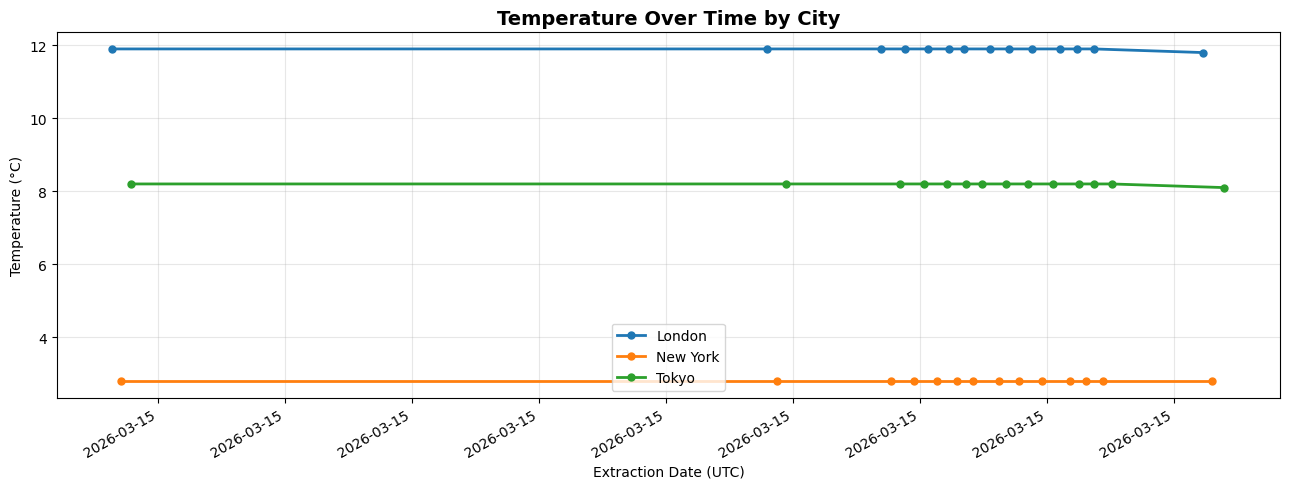

Chart saved ✓


In [6]:
fig, ax = plt.subplots(figsize=(13, 5))

for city, group in df.groupby('city'):
    ax.plot(
        group['extracted_at'],
        group['temperature'],
        marker='o', linewidth=2, markersize=5,
        label=city
    )

ax.set_title('Temperature Over Time by City', fontsize=14, fontweight='bold')
ax.set_xlabel('Extraction Date (UTC)')
ax.set_ylabel('Temperature (°C)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()
ax.legend()
plt.tight_layout()
plt.savefig('../database/chart_temperature_trend.png', dpi=150)
plt.show()
print('Chart saved ✓')

## 4 · Humidity Trend

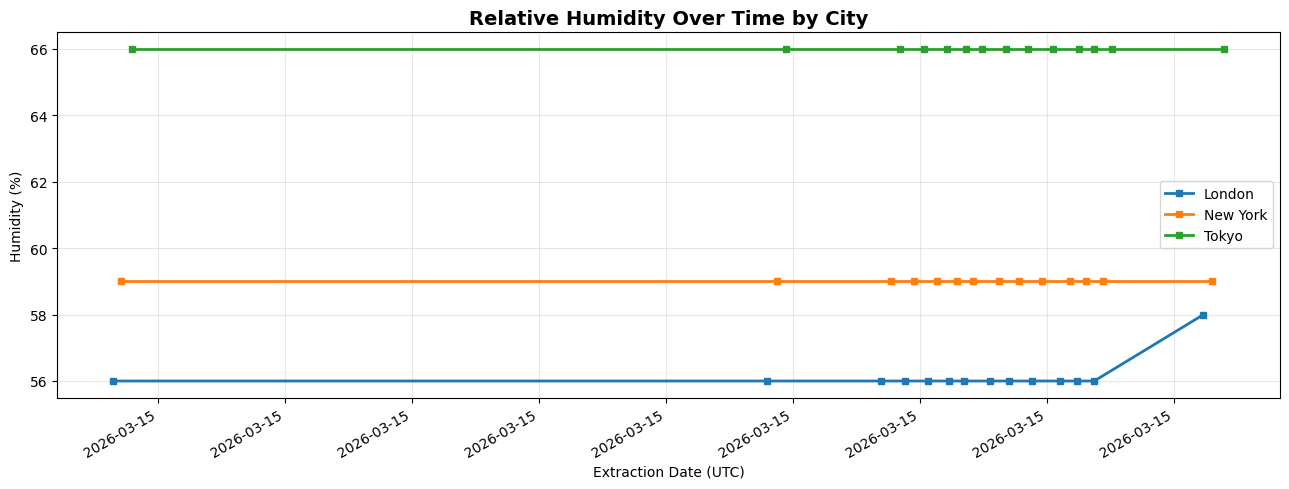

In [7]:
fig, ax = plt.subplots(figsize=(13, 5))

for city, group in df.groupby('city'):
    ax.plot(
        group['extracted_at'],
        group['humidity'],
        marker='s', linewidth=2, markersize=5,
        label=city
    )

ax.set_title('Relative Humidity Over Time by City', fontsize=14, fontweight='bold')
ax.set_xlabel('Extraction Date (UTC)')
ax.set_ylabel('Humidity (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()
ax.legend()
plt.tight_layout()
plt.savefig('../database/chart_humidity_trend.png', dpi=150)
plt.show()

## 5 · Wind Speed Comparison (Bar Chart)

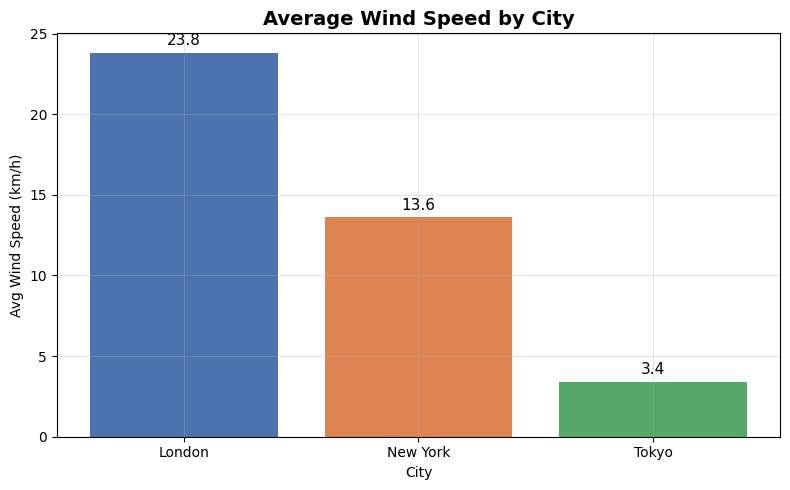

In [8]:
avg_wind = df.groupby('city')['wind_speed'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(avg_wind.index, avg_wind.values, color=['#4C72B0','#DD8452','#55A868'])

# Label each bar
for bar, val in zip(bars, avg_wind.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.1f}',
        ha='center', va='bottom', fontsize=11
    )

ax.set_title('Average Wind Speed by City', fontsize=14, fontweight='bold')
ax.set_xlabel('City')
ax.set_ylabel('Avg Wind Speed (km/h)')
plt.tight_layout()
plt.savefig('../database/chart_wind_speed.png', dpi=150)
plt.show()

## 6 · Temperature vs Feels-Like Scatter

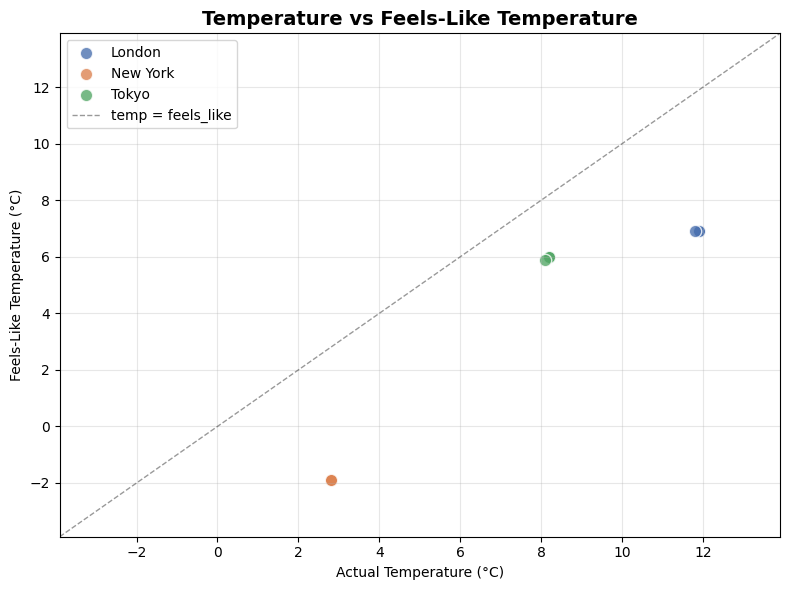

In [9]:
colors = {'London': '#4C72B0', 'New York': '#DD8452', 'Tokyo': '#55A868'}

fig, ax = plt.subplots(figsize=(8, 6))
for city, group in df.groupby('city'):
    ax.scatter(
        group['temperature'],
        group['feels_like'],
        label=city,
        color=colors.get(city, 'grey'),
        s=80, alpha=0.8, edgecolors='white'
    )

# Diagonal reference line (temp == feels_like)
lims = [df[['temperature','feels_like']].min().min() - 2,
        df[['temperature','feels_like']].max().max() + 2]
ax.plot(lims, lims, 'k--', alpha=0.4, linewidth=1, label='temp = feels_like')
ax.set_xlim(lims); ax.set_ylim(lims)

ax.set_title('Temperature vs Feels-Like Temperature', fontsize=14, fontweight='bold')
ax.set_xlabel('Actual Temperature (°C)')
ax.set_ylabel('Feels-Like Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.savefig('../database/chart_temp_vs_feels.png', dpi=150)
plt.show()

## 7 · Latest Snapshot Table

In [10]:
# Most recent record per city
latest = (
    df.sort_values('extracted_at')
      .groupby('city')
      .last()
      .reset_index()
      [['city','temperature','feels_like','humidity','wind_speed','extracted_at']]
)

latest.columns = ['City','Temp (°C)','Feels Like (°C)','Humidity (%)','Wind (km/h)','Last Updated']
latest

,City,Temp (°C),Feels Like (°C),Humidity (%),Wind (km/h),Last Updated
0,London,11.8,6.9,58,24.1,2026-03-15 14:15:03.479657+00:00
1,New York,2.8,-1.9,59,13.6,2026-03-15 14:15:04.513305+00:00
2,Tokyo,8.1,5.9,66,3.4,2026-03-15 14:15:05.952242+00:00


In [11]:
conn.close()
print('Database connection closed ✓')
print('All charts saved to ../database/')

Database connection closed ✓
All charts saved to ../database/
